In [1]:
!nvidia-smi

Wed Dec  4 18:06:30 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   44C    P8             14W /  170W |     993MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import numpy as np
import pandas as pd
# Load the dataset
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

In [3]:
# EDA: Basic overview
print("Dataset Head:\n", df.head())
print("\nDataset Info:\n")
df.info()
print("\nSummary Statistics:\n", df.describe())
print("\nMissing Values Count:\n", df.isnull().sum())

Dataset Head:
    Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transpo

In [4]:
# Check cardinality of categorical features
num_features = tuple(df.select_dtypes(include=['float64']).columns)
cat_features = tuple(df.select_dtypes(include=['object']).columns)
for col in cat_features:
    print(f'{col} value counts')
    print(df[col].value_counts())
    print()

Gender value counts
Gender
Male      1068
Female    1043
Name: count, dtype: int64

family_history_with_overweight value counts
family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64

FAVC value counts
FAVC
yes    1866
no      245
Name: count, dtype: int64

CAEC value counts
CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

SMOKE value counts
SMOKE
no     2067
yes      44
Name: count, dtype: int64

SCC value counts
SCC
no     2015
yes      96
Name: count, dtype: int64

CALC value counts
CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

MTRANS value counts
MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

NObeyesdad value counts
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        

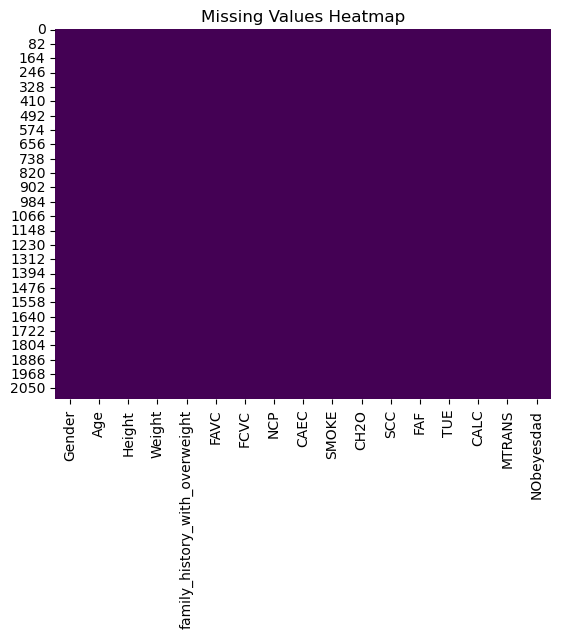

In [5]:
# Visualizing missing values
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

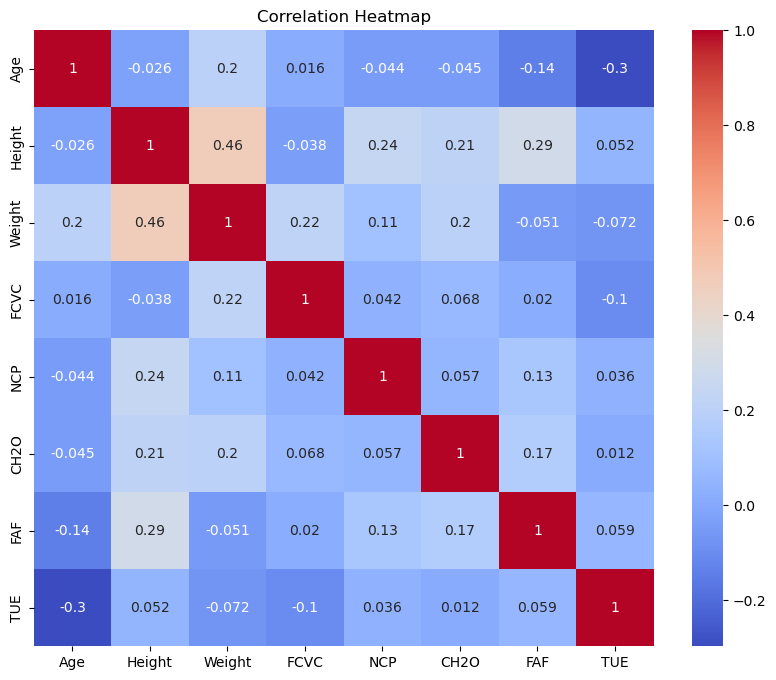

In [6]:
# Correlation Heatmap for numeric columns
numeric_features = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
from sklearn.impute import SimpleImputer
# Handling Missing Values
# Impute missing values based on data type
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

In [8]:
# Convert Binary Vars to 0/1
# Gender
df['Gender'] = (df.Gender == 'Male').astype(int)

# family_history_with_overweight
df.family_history_with_overweight = (df.family_history_with_overweight == 'yes').astype(int)

# FAVC
df.FAVC = (df.FAVC == 'yes').astype(int)

# SMOKE 
df.SMOKE = (df.SMOKE == 'yes').astype(int)

# SCC
df.SCC = (df.SCC == 'yes').astype(int)

In [9]:
# Encode Ordinal Vars
from sklearn.preprocessing import OrdinalEncoder
ord_encoders = {}
ord_vars = ('CAEC', 'CALC', 'NObeyesdad')
ord_vals = [(('no', 'Sometimes', 'Frequently', 'Always'),),
            (('no', 'Sometimes', 'Frequently', 'Always'),),
            (('Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
              'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'),)]
for i, key in enumerate(ord_vars):
    print(f"Encoding {key} with categories: {ord_vals[i]}")
    
    # Extract the inner tuple and wrap it in a list
    categories = [ord_vals[i][0]]
    
    # Initialize the OrdinalEncoder with the correctly structured categories
    ord_encoders[key] = OrdinalEncoder(categories=categories)
    
    # Fit the encoder on the data
    ord_encoders[key].fit(df[[key]])
    
    # Transform the data and create a new encoded column
    col = 'ord_' + key
    df[col] = ord_encoders[key].transform(df[[key]])

Encoding CAEC with categories: (('no', 'Sometimes', 'Frequently', 'Always'),)
Encoding CALC with categories: (('no', 'Sometimes', 'Frequently', 'Always'),)
Encoding NObeyesdad with categories: (('Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'),)


In [10]:
# One-Hot Encode MTRANS
df = pd.concat([df, pd.get_dummies(df.MTRANS).add_prefix('MTRANS_')], axis=1)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,MTRANS,NObeyesdad,ord_CAEC,ord_CALC,ord_NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,...,Public_Transportation,Normal_Weight,1.0,0.0,1.0,False,False,False,True,False
1,0,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,...,Public_Transportation,Normal_Weight,1.0,1.0,1.0,False,False,False,True,False
2,1,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,...,Public_Transportation,Normal_Weight,1.0,2.0,1.0,False,False,False,True,False
3,1,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,...,Walking,Overweight_Level_I,1.0,2.0,2.0,False,False,False,False,True
4,1,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,...,Public_Transportation,Overweight_Level_II,1.0,1.0,3.0,False,False,False,True,False


In [11]:
# Collect Final X vars
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad', 'ord_CAEC', 'ord_CALC',
       'ord_NObeyesdad', 'MTRANS_Automobile', 'MTRANS_Bike',
       'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking'],
      dtype='object')

In [12]:
# Define final X columns
x_cols = ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
          'FAVC', 'FCVC', 'NCP','SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'ord_CAEC',
          'ord_CALC','MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike',
          'MTRANS_Public_Transportation', 'MTRANS_Walking']
df[['ord_NObeyesdad'] + x_cols]

,ord_NObeyesdad,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,...,SCC,FAF,TUE,ord_CAEC,ord_CALC,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1.0,0,21.000000,1.620000,64.000000,1,0,2.0,3.0,0,...,0,0.000000,1.000000,1.0,0.0,False,False,False,True,False
1,1.0,0,21.000000,1.520000,56.000000,1,0,3.0,3.0,1,...,1,3.000000,0.000000,1.0,1.0,False,False,False,True,False
2,1.0,1,23.000000,1.800000,77.000000,1,0,2.0,3.0,0,...,0,2.000000,1.000000,1.0,2.0,False,False,False,True,False
3,2.0,1,27.000000,1.800000,87.000000,0,0,3.0,3.0,0,...,0,2.000000,0.000000,1.0,2.0,False,False,False,False,True
4,3.0,1,22.000000,1.780000,89.800000,0,0,2.0,1.0,0,...,0,0.000000,0.000000,1.0,1.0,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,6.0,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,0,...,0,1.676269,0.906247,1.0,1.0,False,False,False,True,False
2107,6.0,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,0,...,0,1.341390,0.599270,1.0,1.0,False,False,False,True,False
2108,6.0,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,0,...,0,1.414209,0.646288,1.0,1.0,False,False,False,True,False
2109,6.0,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,0,...,0,1.139107,0.586035,1.0,1.0,False,False,False,True,False


In [13]:
# Min Max Scale X Vars
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[x_cols] = scaler.fit_transform(df[x_cols])
df[x_cols].head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,FAF,TUE,ord_CAEC,ord_CALC,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0.0,0.148936,0.320755,0.186567,1.0,0.0,0.5,0.666667,0.0,0.5,0.0,0.000000,0.5,0.333333,0.000000,0.0,0.0,0.0,1.0,0.0
1,0.0,0.148936,0.132075,0.126866,1.0,0.0,1.0,0.666667,1.0,1.0,1.0,1.000000,0.0,0.333333,0.333333,0.0,0.0,0.0,1.0,0.0
2,1.0,0.191489,0.660377,0.283582,1.0,0.0,0.5,0.666667,0.0,0.5,0.0,0.666667,0.5,0.333333,0.666667,0.0,0.0,0.0,1.0,0.0
3,1.0,0.276596,0.660377,0.358209,0.0,0.0,1.0,0.666667,0.0,0.5,0.0,0.666667,0.0,0.333333,0.666667,0.0,0.0,0.0,0.0,1.0
4,1.0,0.170213,0.622642,0.379104,0.0,0.0,0.5,0.000000,0.0,0.5,0.0,0.000000,0.0,0.333333,0.333333,0.0,0.0,0.0,1.0,0.0


In [14]:
# Test Train Split
from sklearn.model_selection import train_test_split
X = df[x_cols]
y = df['ord_NObeyesdad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'X Train {X_train.shape}')
print(f'X Test {X_test.shape}')
print(f'y Train {y_train.shape}')
print(f'y test {y_test.shape}')

X Train (1688, 20)
X Test (423, 20)
y Train (1688,)
y test (423,)


In [15]:
# Install xgboost
!pip install xgboost
# Restart the kernel (manually)
# Import the library and check the version
import xgboost
print(xgboost.__version__)

Defaulting to user installation because normal site-packages is not writeable
2.1.3


In [17]:
# Import RandomForest and XGBoost Classifiers
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Define the models with their respective hyperparameters
rf_model = RandomForestClassifier(n_jobs=-1, random_state=42)
xgb_model = XGBClassifier(n_jobs=-1, use_label_encoder=False, eval_metric='mlogloss', random_state=42)

In [18]:
# Train the Random Forest model
rf_model.fit(X_train, y_train)
print("Random Forest training completed.\n")

Random Forest training completed.



In [19]:
# Train the XGBoost model
xgb_model.fit(X_train, y_train)
print("XGBoost training completed.\n")

XGBoost training completed.



C:\Users\sup161\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [18:11:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [21]:
import joblib
# Save the trained models
joblib.dump({'rf': rf_model, 'xgb': xgb_model}, 'trained_models.joblib')

['trained_models.joblib']

In [22]:
# Load trained models
best_estimators = joblib.load('trained_models.joblib')
rf_model = best_estimators['rf']
xgb_model = best_estimators['xgb']

In [23]:
# Evaluate the models
evaluate = {'Random Forest': rf_model, 'XGBoost': xgb_model}
y_test_str = ord_encoders['NObeyesdad'].inverse_transform(np.asarray(y_test).reshape(-1,1))

for model_name, model in evaluate.items():
    # Predict using the model
    y_pred = ord_encoders['NObeyesdad'].inverse_transform(model.predict(X_test).reshape(-1,1))
    
    # Print classification report
    print(f'Classification Report for {model_name}:\n')
    print(classification_report(y_test_str, y_pred))
    print('-' * 80)

Classification Report for Random Forest:

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.96      0.97        56
      Normal_Weight       0.88      0.90      0.89        62
     Obesity_Type_I       0.99      0.95      0.97        78
    Obesity_Type_II       0.97      0.98      0.97        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.88      0.88      0.88        56
Overweight_Level_II       0.94      0.96      0.95        50

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423

--------------------------------------------------------------------------------
Classification Report for XGBoost:

                     precision    recall  f1-score   support

Insufficient_Weight       0.92      1.00      0.96        56
      Normal_Weight       0.95      0.85    

<Figure size 1000x800 with 0 Axes>

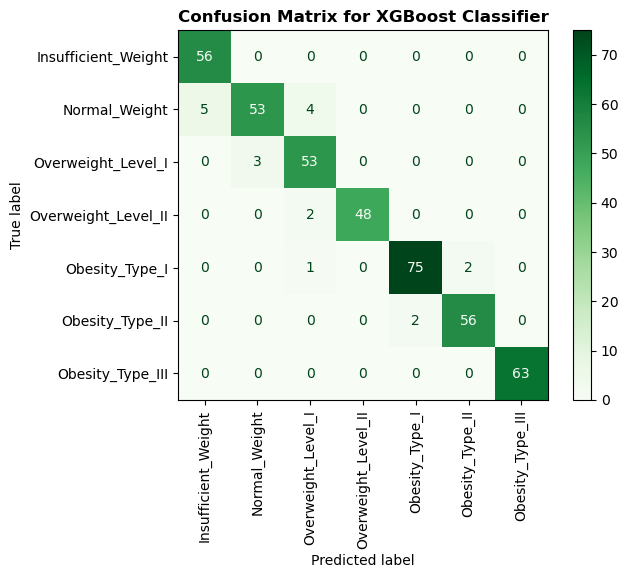

<Figure size 1000x800 with 0 Axes>

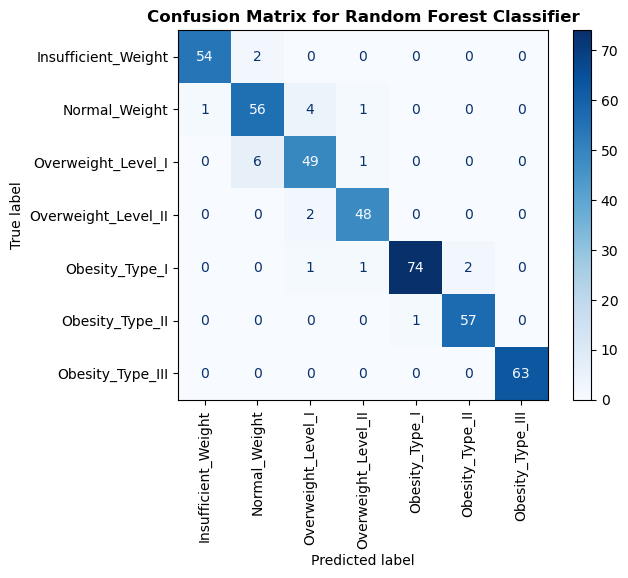

In [25]:
# Compare the models based on their performance
# Plot Confusion Matrices
labels = list(ord_encoders['NObeyesdad'].categories_[0])  # Get category labels

# Confusion Matrix for XGBoost
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    display_labels=labels,
    cmap=plt.cm.Greens,
    xticks_rotation='vertical'
)
plt.title('Confusion Matrix for XGBoost Classifier', fontweight='bold')
plt.grid(False)
plt.show()

# Confusion Matrix for Random Forest
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    display_labels=labels,
    cmap=plt.cm.Blues,
    xticks_rotation='vertical'
)
plt.title('Confusion Matrix for Random Forest Classifier', fontweight='bold')
plt.grid(False)
plt.show()